# Plant Disease Classifier
## Step 6: Evaluate and Test the Model

**What you will learn in this notebook:**
- How to load a saved model
- What accuracy, precision, recall and F1 score mean
- How to run evaluation on the test set
- How to plot and read a confusion matrix
- Save everything as src/evaluate.py

---


---
## Cell 1: Import Libraries

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)

sys.path.append('../src')
from dataset import get_dataloaders
from model import build_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {device}')
print('All imports successful.')

Device : cuda
All imports successful.


---
## Cell 2: Load the Saved Model

We saved the best model weights during training as `best_model.pth`.
Now we load those weights back into a fresh model.

```
state_dict = the saved weights (just numbers, no architecture)
We must first build the model architecture, then load the weights into it.
```

In [3]:
MODEL_PATH = '../outputs/best_model.pth'

# Check if model file exists
if not os.path.exists(MODEL_PATH):
    print(f'Model not found at {MODEL_PATH}')
    print('Please run Step 5 training notebook first.')
else:
    # Step 1: Build the model architecture
    model = build_model(num_classes=2, device=device)

    # Step 2: Load the saved weights into the model
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))

    # Step 3: Set to evaluation mode
    model.eval()

    print('Model loaded successfully.')
    print(f'Weights loaded from : {MODEL_PATH}')
    print(f'Device              : {next(model.parameters()).device}')

Model loaded successfully.
Weights loaded from : ../outputs/best_model.pth
Device              : cuda:0


---
## Cell 3: Load Test Data

In [4]:
DATA_DIR = '../data/PlantVillage'

train_loader, val_loader, test_loader, class_names = get_dataloaders(
    data_dir   = DATA_DIR,
    batch_size = 32
)

print()
print(f'Test batches : {len(test_loader)}')
print(f'Test images  : {len(test_loader.dataset)}')
print()
print('These images were never seen during training.')
print('This is our honest final evaluation.')

Train: 14,446 | Val: 3,096 | Test: 3,096

Test batches : 97
Test images  : 3096

These images were never seen during training.
This is our honest final evaluation.


---
## Cell 4: Understanding Evaluation Metrics

Accuracy alone is not always enough. We use 4 metrics:

```
Accuracy  = (correct predictions) / (total predictions)
           How often is the model right overall?

Precision = (true positives) / (true positives + false positives)
           When model says Diseased, how often is it actually Diseased?

Recall    = (true positives) / (true positives + false negatives)
           Of all Diseased leaves, how many did the model catch?

F1 Score  = 2 * (precision * recall) / (precision + recall)
           Balance between precision and recall
```

For disease detection, Recall is very important.
Missing a diseased plant (false negative) is worse than a false alarm.

In [5]:
# Quick demo of metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example predictions
true_labels = [0, 0, 1, 1, 1, 0, 1, 0]
predictions = [0, 1, 1, 1, 0, 0, 1, 0]   # 2 mistakes

print('Metric Demonstration:')
print('----------------------')
print(f'True labels : {true_labels}')
print(f'Predictions : {predictions}')
print()
print(f'Accuracy  : {accuracy_score(true_labels, predictions)*100:.1f}%')
print(f'Precision : {precision_score(true_labels, predictions)*100:.1f}%')
print(f'Recall    : {recall_score(true_labels, predictions)*100:.1f}%')
print(f'F1 Score  : {f1_score(true_labels, predictions)*100:.1f}%')

Metric Demonstration:
----------------------
True labels : [0, 0, 1, 1, 1, 0, 1, 0]
Predictions : [0, 1, 1, 1, 0, 0, 1, 0]

Accuracy  : 75.0%
Precision : 75.0%
Recall    : 75.0%
F1 Score  : 75.0%


---
## Cell 5: Run Evaluation on Test Set

Now we run the model on all 3,096 test images and collect predictions.

In [6]:
all_preds  = []
all_labels = []
all_probs  = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print('Evaluation complete.')
print(f'Total test images : {len(all_labels)}')
print(f'Correct           : {(all_preds == all_labels).sum()}')
print(f'Wrong             : {(all_preds != all_labels).sum()}')

Evaluation complete.
Total test images : 3096
Correct           : 3083
Wrong             : 13


---
## Cell 6: Print All Metrics

In [7]:
accuracy  = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds) * 100
recall    = recall_score(all_labels, all_preds) * 100
f1        = f1_score(all_labels, all_preds) * 100

print('Test Set Results')
print('=' * 40)
print(f'Accuracy  : {accuracy:.2f}%')
print(f'Precision : {precision:.2f}%')
print(f'Recall    : {recall:.2f}%')
print(f'F1 Score  : {f1:.2f}%')
print()

# Break down by class
healthy_total  = (all_labels == 0).sum()
diseased_total = (all_labels == 1).sum()
healthy_correct  = ((all_labels == 0) & (all_preds == 0)).sum()
diseased_correct = ((all_labels == 1) & (all_preds == 1)).sum()

print('Per Class Results')
print('=' * 40)
print(f'Healthy  : {healthy_correct}/{healthy_total} correct  ({healthy_correct/healthy_total*100:.2f}%)')
print(f'Diseased : {diseased_correct}/{diseased_total} correct  ({diseased_correct/diseased_total*100:.2f}%)')

Test Set Results
Accuracy  : 99.58%
Precision : 99.54%
Recall    : 99.96%
F1 Score  : 99.75%

Per Class Results
Healthy  : 470/482 correct  (97.51%)
Diseased : 2613/2614 correct  (99.96%)


---
## Cell 7: Confusion Matrix

A confusion matrix shows exactly where the model makes mistakes.

```
                  Predicted
                Healthy  Diseased
Actual Healthy  [  TN      FP  ]
Actual Diseased [  FN      TP  ]

TN = True Negative  (correctly said Healthy)
TP = True Positive  (correctly said Diseased)
FP = False Positive (said Diseased but was Healthy)
FN = False Negative (said Healthy but was Diseased)  <- most dangerous!
```

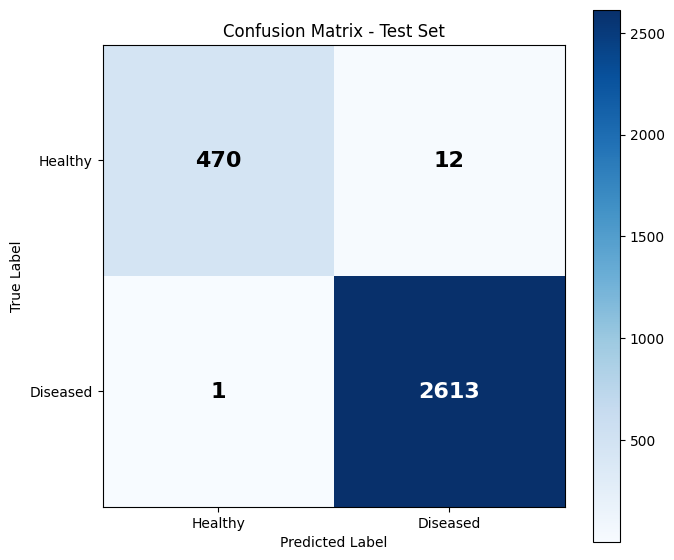

Confusion matrix saved to ../outputs/results/confusion_matrix.png

True Negatives  (Healthy  -> Healthy)  : 470
False Positives (Healthy  -> Diseased) : 12
False Negatives (Diseased -> Healthy)  : 1
True Positives  (Diseased -> Diseased) : 2613


In [8]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

classes = ['Healthy', 'Diseased']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix - Test Set')

# Add numbers inside each cell
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/results/confusion_matrix.png', dpi=150)
plt.show()

print('Confusion matrix saved to ../outputs/results/confusion_matrix.png')
print()
print(f'True Negatives  (Healthy  -> Healthy)  : {cm[0][0]}')
print(f'False Positives (Healthy  -> Diseased) : {cm[0][1]}')
print(f'False Negatives (Diseased -> Healthy)  : {cm[1][0]}')
print(f'True Positives  (Diseased -> Diseased) : {cm[1][1]}')

---
## Cell 8: Show Some Predictions Visually

Let us look at actual leaf images with their true and predicted labels.

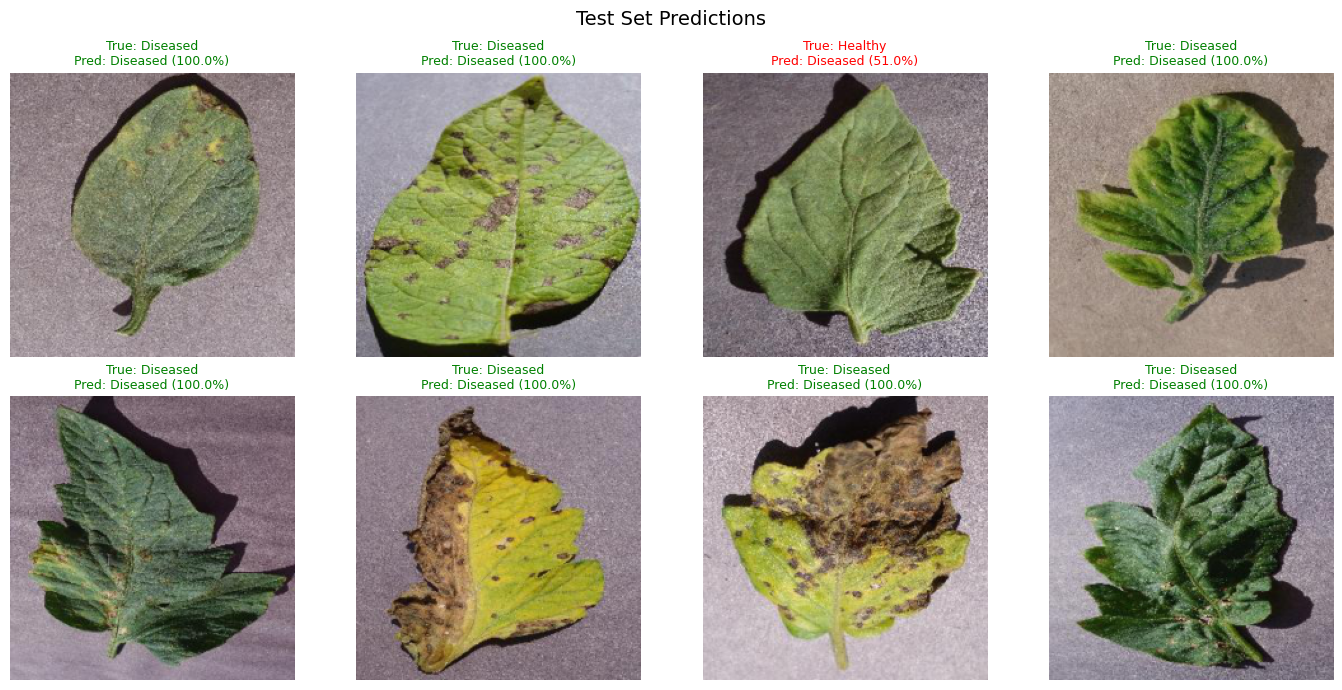

In [9]:
# Get one batch from test loader
images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

with torch.no_grad():
    outputs = model(images_batch)
    probs   = torch.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1)

# Helper to undo normalization for display
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

label_names = ['Healthy', 'Diseased']

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Test Set Predictions', fontsize=14)

for i, ax in enumerate(axes.flat):
    img        = denormalize(images_batch[i]).permute(1, 2, 0).numpy()
    true_label = labels_batch[i].item()
    pred_label = preds[i].item()
    confidence = probs[i][pred_label].item() * 100
    correct    = true_label == pred_label

    ax.imshow(img)
    ax.set_title(
        f'True: {label_names[true_label]}\n'
        f'Pred: {label_names[pred_label]} ({confidence:.1f}%)',
        color='green' if correct else 'red',
        fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Cell 9: Save as src/evaluate.py

In [10]:
evaluate_code = '''
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def evaluate(model, loader, device):
    """
    Runs model on a dataloader and returns predictions and true labels.
    """
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


def print_metrics(preds, labels):
    """
    Prints accuracy, precision, recall and F1 score.
    """
    print(f"Accuracy  : {accuracy_score(labels, preds)*100:.2f}%")
    print(f"Precision : {precision_score(labels, preds)*100:.2f}%")
    print(f"Recall    : {recall_score(labels, preds)*100:.2f}%")
    print(f"F1 Score  : {f1_score(labels, preds)*100:.2f}%")
'''

with open('../src/evaluate.py', 'w') as f:
    f.write(evaluate_code)

print('src/evaluate.py saved successfully.')
print()
print('Step 6 Complete!')
print('Next: Step 7 - Predict on New Images')

src/evaluate.py saved successfully.

Step 6 Complete!
Next: Step 7 - Predict on New Images


---
## Step 6 Summary

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| Test set | Data never seen during training | Honest final evaluation |
| Accuracy | Overall correct predictions | General performance measure |
| Precision | Correct among predicted diseased | Avoid false alarms |
| Recall | Caught among all diseased | Avoid missing diseases |
| F1 Score | Balance of precision and recall | Single overall metric |
| Confusion matrix | Shows where model makes mistakes | Understand failure cases |
| state_dict | Saved model weights | Reuse model without retraining |

---
